<a href="https://colab.research.google.com/github/MehulShukla-git/Movie_Recommendation_System/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SVM**

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [13]:
df = pd.read_csv('/content/drive/MyDrive/movies_metadata.csv',
                 sep=',',
                 engine='python',
                 on_bad_lines='skip')

print(df.columns)

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')


In [14]:
df = df[['title','overview','genres','tagline','vote_average','popularity']]

df = df.dropna(subset=['title'])

df['overview'] = df['overview'].fillna('')
df['tagline'] = df['tagline'].fillna('')

In [15]:
import ast

def extract_genres(x):
    try:
        return " ".join([i['name'] for i in ast.literal_eval(x)])
    except:
        return ""

df['genres'] = df['genres'].apply(extract_genres)

df['tags'] = df['overview'] + " " + df['genres'] + " " + df['tagline']

In [16]:
import nltk, re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

df['tags'] = df['tags'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['tags'])

# Target
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce').fillna(0)
y = df['vote_average'].apply(lambda x: 1 if x >= 6 else 0)

X_dense = X.toarray()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import *

# 70-30 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

svm = LinearSVC()
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
y_score = svm.decision_function(X_test)

acc = accuracy_score(y_test, y_pred)

print("===== (70-30) =====")
print("Accuracy :", acc)
print("Accuracy % :", acc * 100)
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_score))

===== (70-30) =====
Accuracy : 0.5792638216747323
Accuracy % : 57.926382167473236
Precision: 0.6006318283532973
Recall   : 0.627906976744186
F1 Score : 0.6139666307857912
ROC-AUC  : 0.6041572003766811


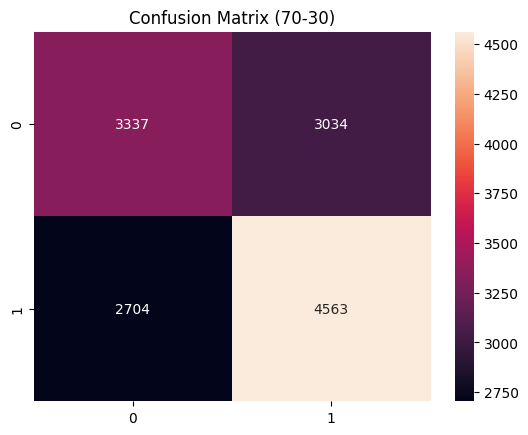

In [19]:
# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (70-30)")
plt.show()

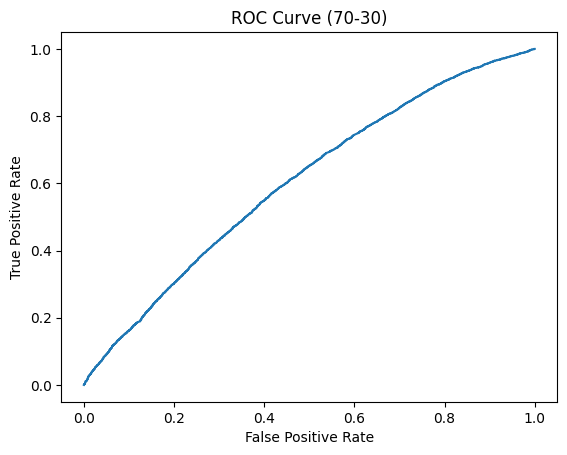

In [20]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve (70-30)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import *
import seaborn as sns
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

svm = LinearSVC()
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
y_score = svm.decision_function(X_test)

acc = accuracy_score(y_test, y_pred)

print("\n===== (80-20) =====")
print("Accuracy :", acc)
print("Accuracy % :", acc * 100)
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_score))


===== (80-20) =====
Accuracy : 0.5801803783545975
Accuracy % : 58.018037835459744
Precision: 0.5963879073419709
Recall   : 0.6330485517816211
F1 Score : 0.6141716365106641
ROC-AUC  : 0.608283803205177


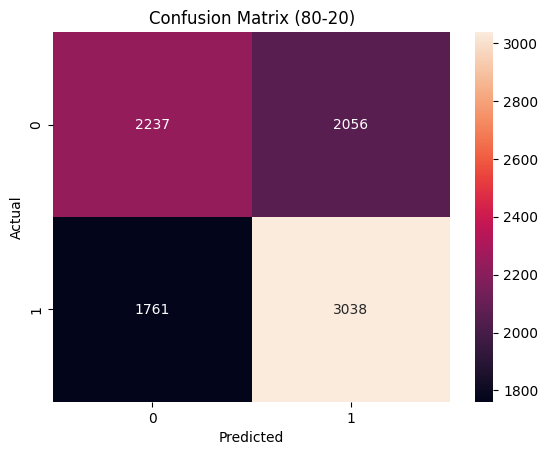

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (80-20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

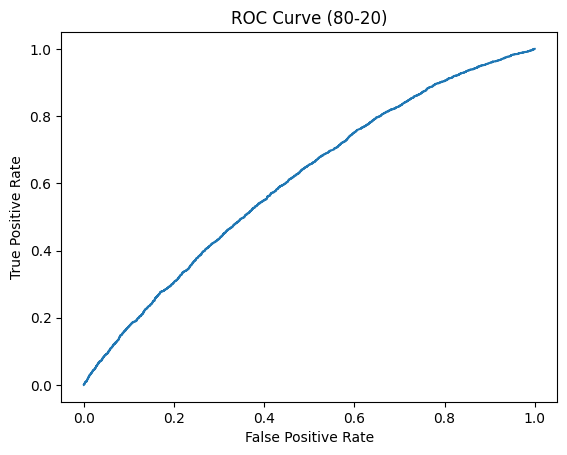

In [24]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve (80-20)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()